# Figure Generation


In [2]:
import os  # For handling file paths and directories
import pandas as pd  # For working with tabular data using DataFrames
import matplotlib.pyplot as plt  # For generating plots
import zipfile  # For reading compressed files without extracting them
import re  # For extracting numerical IDs using regular expressions

import torch
import random
import numpy as np

import os
import pandas as pd
import numpy as np

import networkx as nx  # For graph-level metrics

BASE_DIR = "../../../input_columns_1mm/input_columns"
SUBJECT_IDS_CSV = "../../age_prediction_on_columns_analyses/subject_ids.csv"
AGE_CSV = "../../age_prediction_on_columns_analyses/ages.csv"
METADATA_PATH = "../../../AD_DECODE_data3.xlsx"
THICKNESS_DIR = '../../../thickness_in_region'

In [3]:
# List of hemispheres
HEMIS = ["lh", "rh"]

# List of cortical regions (based on the parcellation used)
REGION_NAMES = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]

In [4]:
# Paths to CSVs
SUBJECT_IDS_CSV = SUBJECT_IDS_CSV
AGE_CSV = AGE_CSV

# Load both files (no headers)
subject_df = pd.read_csv(SUBJECT_IDS_CSV, header=None)
age_df = pd.read_csv(AGE_CSV, header=None)

# Zero-pad subject IDs to 5 digits
subject_ids = subject_df[0].astype(str).apply(lambda x: x.zfill(5)).tolist()
ages = age_df[0].astype(float).tolist()

# Build dictionary: subject_id → age
age_dict = dict(zip(subject_ids, ages))

In [ ]:
# Final dictionary: subject_id -> region -> matrix
column_data = {}

# Loop through subjects
for subj_id in subject_ids:
    subj_dict = {}
    subj_dir = os.path.join(BASE_DIR, f"S{subj_id}_columns_1mm")
    subj_dir_to_thickness = os.path.join(THICKNESS_DIR, f"S{subj_id}")  # Path to subject's thickness folder

    for hemi in HEMIS:
        for region in REGION_NAMES:
            region_key = f"{hemi}_{region}"
            filename = f"S{subj_id}_{region_key}_md.csv"
            # Construct full file paths
            filepath = os.path.join(subj_dir, filename)

            if not os.path.exists(filepath):
                print(f"[WARNING] Missing: {filepath}")
                continue

            mat = pd.read_csv(filepath, header=None).values.astype(np.float32)
            subj_dict[region_key] = mat

    if len(subj_dict) > 0:
        column_data[subj_id] = subj_dict
    else:
        print(f"[INFO] Skipping subject {subj_id} (no valid regions)")


In [10]:
# For each region, plot the md values vs. age for different depths

# Create a directory for saving figures if it doesn't exist
output_dir = "MD_vs_age_figures"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Create a color list for different depths
colors = plt.cm.viridis(np.linspace(0, 1, 21))  # 21 depths, adjust as needed
for hemi in HEMIS:
    for region in REGION_NAMES:
        region_key = f"{hemi}_{region}"
        plt.figure(figsize=(10, 6))
        plt.title(f"MD Values vs Age for {region_key}")

        for depth in range(21):  # Assuming 21 depths, adjust as needed
            md_values = []
            ages = []
            for subj_id, regions in column_data.items():
                if region_key in regions:
                    md_values.append(regions[region_key][:, depth])
                    ages.append(age_dict[subj_id])
            if md_values and ages:
                # Convert to numpy arrays for plotting
                md_values = np.concatenate(md_values)
                ages = np.array(ages)

                # Scatter plot for this depth
                plt.scatter(ages, md_values, color=colors[depth], label=f"Depth {depth + 1}", alpha=0.5)

        plt.xlabel("Age")
        plt.ylabel("MD Values")
        # Plot legend aside the plot
        plt.legend(title="Depths", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid()
        plt.savefig(os.path.join(output_dir, f"{region_key}_MD_vs_Age.png"), bbox_inches='tight')
        plt.close()

In [13]:
# The list of top 6 regions with highest mean absolute SHAP values
top_regions = [
    'rh_cuneus', 'lh_entorhinal',
    'lh_cuneus', 'rh_entorhinal',
    'lh_transversetemporal', 'lh_pericalcarine']

# Create a directory for saving figures if it doesn't exist
output_dir = "MD_vs_age_figures_top_regions"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for region in top_regions:
    region_key = region
    plt.figure(figsize=(10, 6))
    plt.title(f"MD Values vs Age for {region_key}")

    for depth in range(21):  # Assuming 21 depths, adjust as needed
        md_values = []
        ages = []
        for subj_id, regions in column_data.items():
            if region_key in regions:
                md_values.append(regions[region_key][:, depth])
                ages.append(age_dict[subj_id])
        if md_values and ages:
            # Convert to numpy arrays for plotting
            md_values = np.concatenate(md_values)
            ages = np.array(ages)

            # Scatter plot for this depth
            plt.scatter(ages, md_values, color=colors[depth], label=f"Depth {depth + 1}", alpha=0.5)

    plt.xlabel("Age")
    plt.ylabel("MD Values")
    # Plot legend aside the plot
    plt.legend(title="Depths", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid()
    plt.savefig(os.path.join(output_dir, f"{region_key}_MD_vs_Age.png"), bbox_inches='tight')
    plt.close()

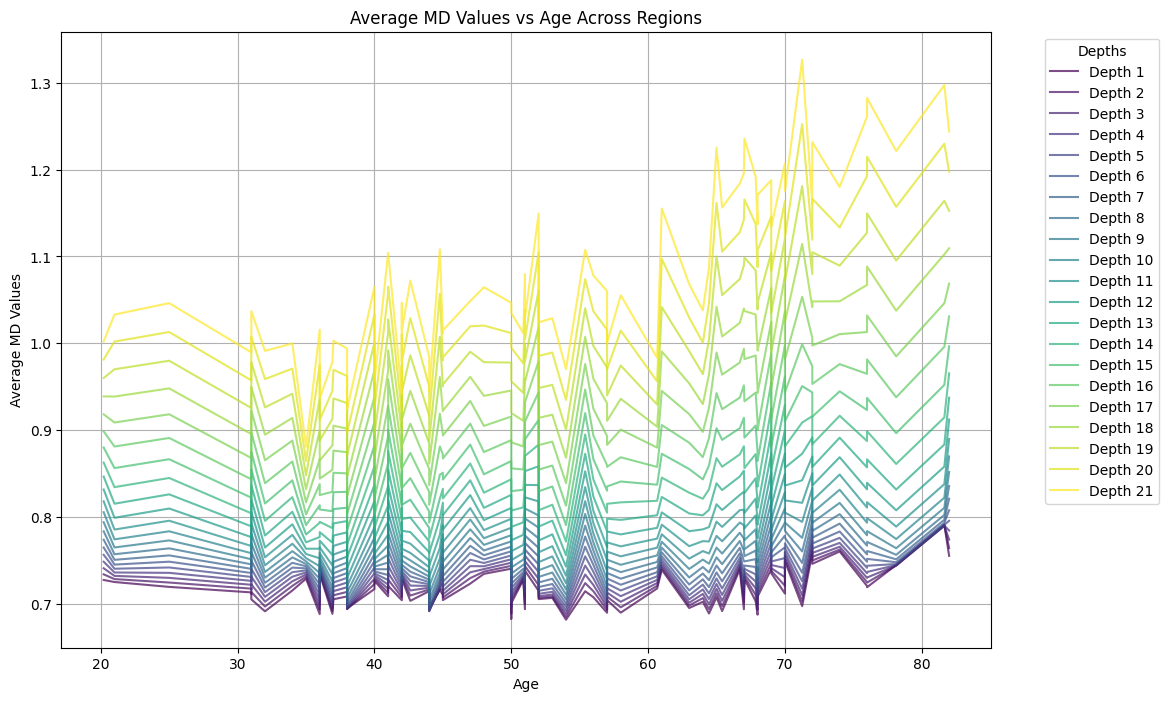

In [16]:
# Line plots: Mean MD vs. Age per depth layer (across regions)
# Average MD values across all regions for each subject
average_md_values = {}
for subj_id, regions in column_data.items():
    average_md_values[subj_id] = {}
    for depth in range(21):  # Assuming 21 depths, adjust as needed
        avg_md = np.mean([regions[region_key][:, depth] for region_key in regions], axis=0)
        average_md_values[subj_id][depth] = avg_md

# Plotting the average MD values vs. age for each depth layer
plt.figure(figsize=(12, 8))
for depth in range(21):  # Assuming 21 depths, adjust as needed
    md_values = []
    ages = []
    for subj_id, avg_md in average_md_values.items():
        md_values.append(avg_md[depth])
        ages.append(age_dict[subj_id])
    
    if md_values and ages:
        # Convert to numpy arrays and resort by age
        md_values = np.array(md_values)
        ages = np.array(ages)
        sorted_indices = np.argsort(ages)
        md_values = md_values[sorted_indices]
        ages = ages[sorted_indices]
        plt.plot(ages, md_values, label=f"Depth {depth + 1}", color=colors[depth], linestyle='-', alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Average MD Values")
plt.title("Average MD Values vs Age Across Regions")
# Plot legend aside the plot
plt.legend(title="Depths", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()


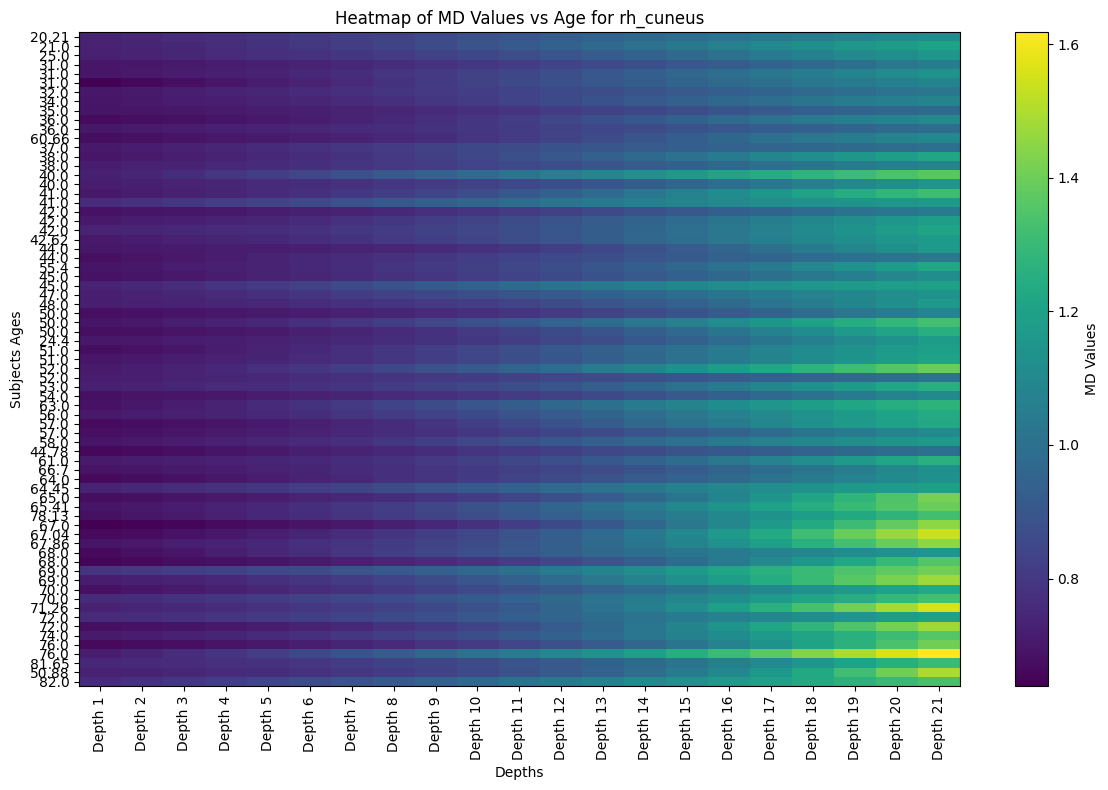

In [22]:
# Heatmap of age-wise MD per depth in a representative region

region = 'rh_cuneus'

# Plotting the heatmap
plt.figure(figsize=(12, 8))
# Extract MD values and ages for the specified region
md_values = []
ages = []
for subj_id, regions in column_data.items():
    if region in regions:
        md_values.append(regions[region][:, :])  # All depths
        ages.append(age_dict[subj_id])
md_values = np.array(md_values)
ages = np.array(ages)
# Remove singleton dimension if present
md_values = np.squeeze(md_values)  # shape becomes (71, 21)
# Sort by age
sorted_indices = np.argsort(ages)
md_values = md_values[sorted_indices]
ages = ages[sorted_indices]
# Create a heatmap
plt.imshow(md_values, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(label='MD Values')
plt.title(f"Heatmap of MD Values vs Age for {region}")
plt.xlabel("Depths")
plt.ylabel("Subjects Ages")
plt.xticks(ticks=np.arange(md_values.shape[1]), labels=[f"Depth {i + 1}" for i in range(md_values.shape[1])], rotation=90)
plt.yticks(ticks=np.arange(md_values.shape[0]), labels=[f"{age_dict[subj_id]}" for subj_id in np.array(subject_ids)[sorted_indices]])
plt.tight_layout()
plt.show()